# 1. Cvičení: Amplitudová Modulace

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd

In [4]:
"""Ac: Amplituda nosné vlny.
frekvence: Frekvence nosné vlny.
n_length: Délka signálu (počet vzorků).
t: Pole hodnot času.
Tato funkce generuje nosnou vlnu o amplitudě Ac a frekvenci frekvence. Používá se k vytvoření čisté nosné vlny."""

def nos_vlna(Ac, frekvence, n_length, t):
    uhl_frek = 2 * np.pi * frekvence
    f = Ac * np.sin(uhl_frek * t)
    return np.array(f)

"""m: Modulační index (určuje amplitudu modulačního signálu).
fm: Frekvence modulačního signálu.
Ac: Amplituda nosné vlny.
fc: Frekvence nosné vlny.
t: Pole hodnot čas  

Tato funkce generuje modulační signál AM.

Nejprve volá funkci nos_vlna pro vytvoření nosné vlny nosna s frekvencí fc.
Poté kombinuje nosnou vlnu s modulační složkou, kde amplituda nosné vlny je modulována podle kosinové složky (1 + m * np.cos(2 * np.pi * fm * t)). To přesně odpovídá vzorci amplitudové modulace.

"""

def mod_vlna(m, fm, Ac, fc, t):
    nosna = nos_vlna(Ac, fc, len(t), t)  
    modulacni_signal = (1 + m * np.cos(2 * np.pi * fm * t)) * nosna
    return modulacni_signal


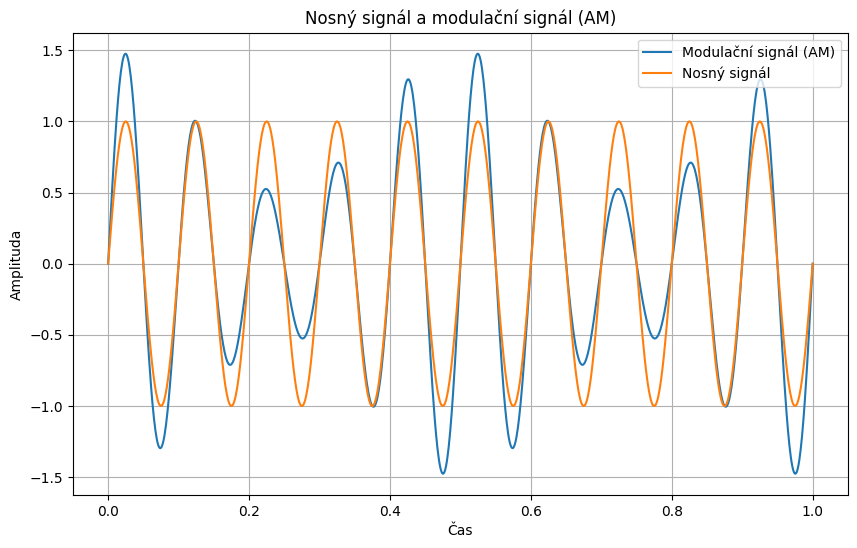

In [5]:
t = np.linspace(0, 1, 1000)  # časový interval
Ac = 1.0  # Amplituda nosné vlny
fc = 10.0  # Frekvence nosné vlny
m = 0.5  # Modulační index
fm = 2.0  # Frekvence modulačního signálu

modulacni_signal = mod_vlna(m, fm, Ac, fc, t)
nosni_signal = nos_vlna(Ac, fc, len(t), t)

plt.figure(figsize=(10, 6))
plt.plot(t, modulacni_signal, label='Modulační signál (AM)')
plt.plot(t, nosni_signal, label='Nosný signál')
plt.title('Nosný signál a modulační signál (AM)')
plt.xlabel('Čas')
plt.ylabel('Amplituda')
plt.legend()
plt.grid(True)
plt.show()




# 2. Cvičení: Pilový signál

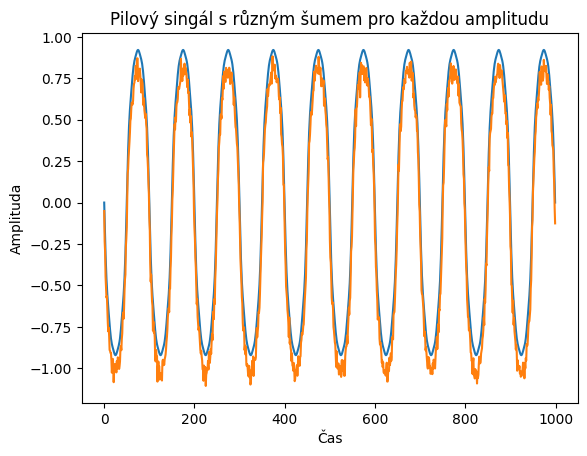

In [6]:
"""
Pilový signál je typ periodického signálu, který má charakteristický tvar podobný pilu nebo zubu pilu. Tento typ signálu se často používá v elektronice, signálovém zpracování a telekomunikacích. Pilový signál má následující vlastnosti:
-> Periodicita: Pilový signál se pravidelně opakuje v pravidelných intervalech. Doba, za kterou se signál opakuje, se nazývá perioda.
-> Lineární vzrůst a pokles: Pilový signál se charakterizuje lineárním nárůstem (stoupáním) amplitudy během první poloviny periody a lineárním poklesem (klesáním) amplitudy během druhé poloviny periody. 
   Toto stoupání a pokles může mít různé úhlové rychlosti, což ovlivňuje tvar pilového signálu.
-> Neustálý skokový přechod: Pilový signál obsahuje skokový přechod mezi stoupající a klesající částí, kde amplituda rychle mění svou hodnotu.

Pilové signály se používají v různých aplikacích, jako jsou generátory zvuku, analýza signálů, komunikace a modulace signálů. 
Jsou jedním z jednoduchých typů periodických signálů a mají matematicky definovaný tvar, což usnadňuje jejich analýzu a použití v různých oblastech techniky a vědy.
"""



import scipy.signal as sig
import numpy as np
import random as rnd

xsig = np.zeros(100)

tsigs = np.linspace(0,1,500)
per = 2 * np.pi
num = 5
xsigs = sig.sawtooth(tsigs*per*num, 0.5)

#plt.plot(tsigs, xsigs)

#Pilový signál
def f(frek, t, n):
    x = np.zeros_like(t)
    n = 1
    for n in range(n,10, 2):
        x += -1 * np.sin(2 * n * np.pi * frek * t) / n**2
    return x

xxx = f(10, np.linspace(0, 1, 1000), 10)

plt.plot(xxx)
plt.title("Pilový singál")
plt.ylabel("Amplituda")
plt.xlabel("Čas")

#Signál s chybyou

def f(frek, t, n):
    x = np.zeros_like(t)
    for i in range(1, n + 1, 2):
        rndcisla = np.random.uniform(-0.05, 0.005, size=len(t))  # Náhodný šum pro každou amplitudu
        x += (-1) * np.sin(2 * i * np.pi * frek * t) / i**2 + rndcisla
    return x

xxx = f(10, np.linspace(0, 1, 1000), 10)

plt.plot(xxx)
plt.title("Pilový singál s různým šumem pro každou amplitudu")
plt.ylabel("Amplituda")
plt.xlabel("Čas")
plt.show()

## Náhodný signál a trend signálu

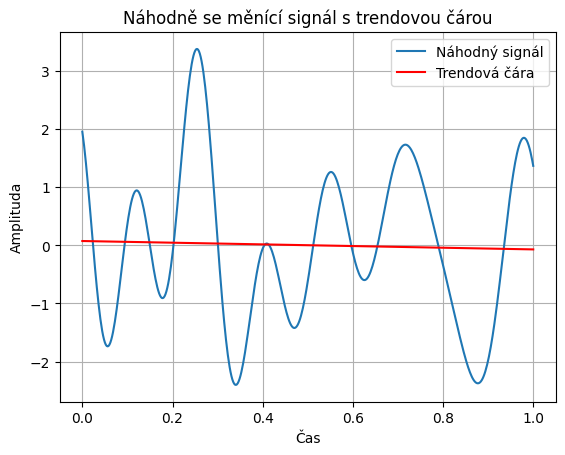

In [7]:
"""
Trend signálu:
 -> Trend signálu je dlouhodobý směr nebo obecný směr, který vykazuje časová řada nebo datový signál. Trend může být stoupající, klesající nebo stabilní. 
    Je to indikace toho, jak se data vyvíjejí nebo mění v čase. Trend může být spojován s různými faktory, jako jsou ekonomické ukazatele, demografické změny, sezónní vlivy nebo jiné proměnné.
 -> Trend signálu může být lineární, což znamená, že se vyvíjí lineárně, nebo nelineární, pokud je jeho vývoj složitější a nelze ho popsat jednoduchou přímkou.

Lineární regrese:
 ->Lineární regrese je statistická metoda používaná k analýze vztahu mezi dvěma nebo více proměnnými, z nichž jedna je považována za nezávislou a druhá za závislou. 
   Cílem lineární regrese je nalézt lineární vztah mezi těmito proměnnými, což může pomoci předpovědět hodnoty závislé proměnné na základě hodnoty nezávislé proměnné.
-> Lineární regrese předpokládá, že závislá proměnná je lineárně závislá na nezávislé proměnné a tento vztah je obvykle popisován lineární rovnicí ve tvaru y = a * x + b,
   kde y je závislá proměnná, x je nezávislá proměnná, a je sklon (koeficient) regresní přímky a b je intercept (posun) regresní přímky. Lineární regrese se používá k modelování trendů, predikci budoucích hodnot a analýze vztahu mezi proměnnými.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def nahodny_signal(frek, t):
    seznam = np.zeros_like(t)
    for i in range(1, 10):
        random_noise = np.sin(i + t * np.random.random() * frek)
        seznam += random_noise
    return seznam

t = np.linspace(0, 1, 500)
xxx = nahodny_signal(50, t)

# Lineární regrese pro výpočet trendové čáry
slope, intercept, _, _, _ = linregress(t, xxx)
trend_line = slope * t + intercept

plt.plot(t, xxx, linestyle='-', label='Náhodný signál')
plt.plot(t, trend_line, color='red', label='Trendová čára')
plt.title("Náhodně se měnící signál s trendovou čárou")
plt.xlabel("Čas")
plt.ylabel("Amplituda")
plt.grid(True)
plt.legend()
plt.show()


# 3. Cvičení: Konvoluce

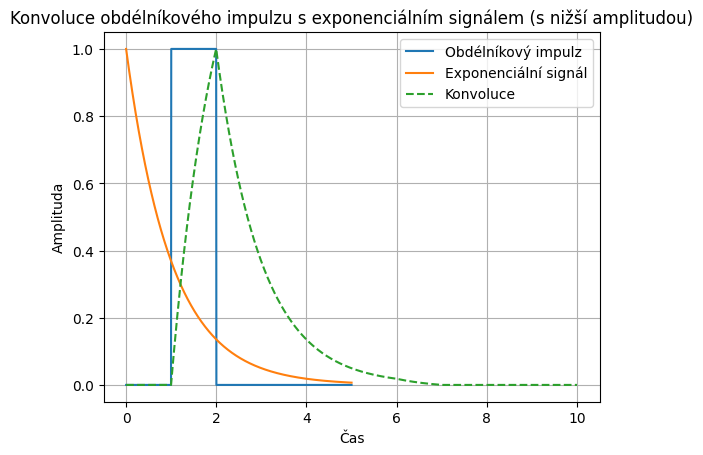

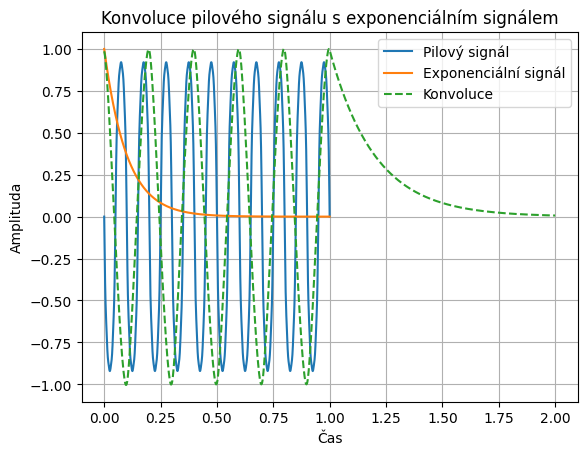

In [8]:
"""
Konvoluce je matematický operátor a základní pojem v mnoha oblastech, včetně matematiky, fyziky, inženýrství a zejména v oblasti zpracování signálů a zpracování obrazu. 
V kontextu zpracování obrazu a signálů se konvoluce používá k analýze a transformaci dat.

-> Zpracování obrazu: V oblasti zpracování obrazu se konvoluce používá k aplikaci různých filtrů na obrázky. Tyto filtry mohou například detekovat hrany, rozostřit obrazy nebo provádět další úpravy.

-> Zpracování signálů: V telekomunikacích a audio zpracování se konvoluce používá k filtraci signálů, například pro odstranění šumu, změnu frekvenčního obsahu a další úpravy.

-> Matematická analýza: Konvoluce se používá v matematice a fyzice k řešení různých diferenciálních rovnic a problémů spojených s distribucí.

-> Strojové učení: Konvoluce je také klíčovým prvkem v konvolučních neuronových sítích (CNN), což jsou hluboké neuronové sítě, které jsou široce používány v oblasti počítačového vidění a analýzy obrazu.

Celkově lze konvoluci chápat jako způsob, jakým se informace šíří a transformuje v různých typech dat, a má mnoho praktických aplikací v různých oblastech.
"""



#Konvolace obdelníku/čtverce exponenciálou

def generuj_obdelnik(amp, t):
    seznam = [amp if 0 <= (time - 1) < 1 else 0 for time in t]
    return seznam

def generuj_exponencialu(tau, t):
    return  np.exp(-t / tau)  # Změna amplitudy exponenciálního signálu na 0.5

t = np.linspace(0,5, 1000)
x_obdelnik = generuj_obdelnik(1, t)
x_exponenciala = generuj_exponencialu(1, t)

# Konvoluce obdélníkového impulzu s exponenciálním signálem
konvoluce = np.convolve(x_obdelnik, x_exponenciala, 'full')
konvoluce = konvoluce/np.max(konvoluce)

# Nastavení časového intervalu pro zobrazení konvoluce
t_konvoluce = np.linspace(0, 10, len(konvoluce))

plt.plot(t, x_obdelnik, label='Obdélníkový impulz')
plt.plot(t, x_exponenciala, label='Exponenciální signál')
plt.plot(t_konvoluce, konvoluce, label='Konvoluce', linestyle='--')
plt.xlabel('Čas')
plt.ylabel('Amplituda')
plt.title('Konvoluce obdélníkového impulzu s exponenciálním signálem (s nižší amplitudou)')
plt.grid(True)
plt.legend()
plt.show()

#Generování pilového signálu a následná konvoluce exponencialou


def f(frek, t, n):
    x = np.zeros_like(t)
    for n in range(1, n, 2):
        x += -1 * np.sin(2 * n * np.pi * frek * t) / n**2
    return x

def generuj_exponencialu(tau, t):
    return np.exp(-t / tau)

t_pilovy_signal = np.linspace(0, 1, 1000)
xxx = f(10, t_pilovy_signal, 10)

t_exponenciala = np.linspace(0, 1, 1000)
exponenciala = generuj_exponencialu(0.1, t_exponenciala)

# Konvoluce pilového signálu s exponenciálním signálem
konvoluce = np.convolve(xxx, exponenciala, 'same')

konvoluce = konvoluce/np.max(konvoluce)

# Nastavení časového intervalu pro zobrazení konvoluce
t_konvoluce = np.linspace(0, 2, len(konvoluce))

plt.plot(t_pilovy_signal, xxx, label='Pilový signál')
plt.plot(t_exponenciala, exponenciala, label='Exponenciální signál')
plt.plot(t_konvoluce, konvoluce, label='Konvoluce', linestyle='--')
plt.xlabel('Čas')
plt.ylabel('Amplituda')
plt.title('Konvoluce pilového signálu s exponenciálním signálem')
plt.grid(True)
plt.legend()
plt.show()



# 4. Cvičení: Kovariance, Korelace

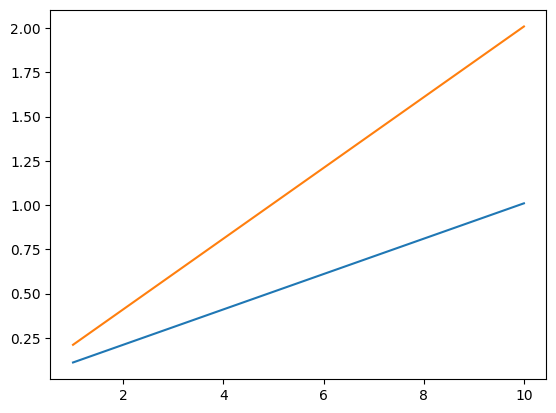

[[0.06790635 0.13581271]
 [0.13581271 0.27162542]]


In [9]:
"""
Korelace je statistický koncept, který se používá k popisu vztahu mezi dvěma nebo více proměnnými. 
Tento vztah se měří číslem nazývaným korelační koeficient, který vyjadřuje, jakým způsobem se tyto proměnné vzájemně mění. Korelační koeficient nabývá hodnoty v rozmezí od -1 do 1, kde:

-> Kladná korelace (0 < r < 1): Pokud korelační koeficient je kladný, znamená to, že existuje pozitivní vztah mezi proměnnými. 
    To znamená, že pokud se jedna proměnná zvýší, druhá pravděpodobně také stoupne, a naopak, pokud se jedna proměnná sníží, druhá pravděpodobně také klesne.

-> Záporná korelace (-1 < r < 0): Pokud je korelační koeficient záporný, naznačuje to negativní vztah mezi proměnnými. 
    To znamená, že pokud se jedna proměnná zvýší, druhá pravděpodobně klesne, a naopak, pokud se jedna proměnná sníží, druhá pravděpodobně stoupne.

-> Žádná korelace (r = 0): Pokud je korelační koeficient blízký nule, naznačuje to, že mezi proměnnými není žádný významný vztah. 
    Změny v jedné proměnné nejsou spojeny s žádnými systematickými změnami v druhé proměnné.

-> Korelace nám umožňuje měřit, jak dobře dvě proměnné souvisejí mezi sebou, a to má široké uplatnění v různých oborech, jako je statistika, ekonomie, psychologie, medicína a další. 
    Je důležité si uvědomit, že korelace neznamená nutně příčinný vztah mezi proměnnými. Pouze ukazuje, jak jsou tyto proměnné vzájemně propojeny, ale nemusí nám říct, proč se tak děje.


Kovariance je statistický koncept, který měří míru, jakým dvě náhodné proměnné mění své hodnoty společně. 
Konkrétně popisuje, zda změna v jedné proměnné souvisí se změnou v druhé proměnné. 
Kovariance se často používá k analýze vztahů mezi dvěma proměnnými a je základním krokem při výpočtu korelačního koeficientu, který jsme zmínili v předchozím vysvětlení.

-> Kladná kovariance (cov(X, Y) > 0): Pokud kovariance je kladná, naznačuje to, že pokud se hodnoty jedné proměnné zvýší, 
    hodnoty druhé proměnné také pravděpodobně stoupnou, a naopak, pokud se hodnoty jedné proměnné sníží, hodnoty druhé proměnné pravděpodobně klesnou. To indikuje pozitivní vztah mezi proměnnými.

-> Záporná kovariance (cov(X, Y) < 0): Pokud je kovariance záporná, naznačuje to, že pokud se hodnoty jedné proměnné zvýší, hodnoty druhé proměnné pravděpodobně klesnou, a naopak. 
    To ukazuje na negativní vztah mezi proměnnými.

-> Nulová kovariance (cov(X, Y) = 0): Pokud je kovariance nulová, znamená to, že mezi proměnnými neexistuje systematický vztah.
    Změny v jedné proměnné nejsou spojeny s žádnými změnami v druhé proměnné.

-> Kovariance má své omezení v tom, že její hodnota závisí na měřítku proměnných, které se zkoumají, a nemá jednotky. 
    To vedlo k vytvoření korelačního koeficientu, který normalizuje kovarianci tak, aby byl nezávislý na jednotkách proměnných a nabýval hodnot v rozmezí -1 až 1, což usnadňuje interpretaci vztahu mezi proměnnými.

"""

N = 500

def f1(a,b,x):
   return a+b*x

def f2 (a,b,x):
    return a+b*x

x = np.linspace(1,10,N)
funkce1 = f1(0.01, 0.1, x)
funkce2 = f2(0.01, 0.2, x)

plt.plot(x, funkce1, x, funkce2)
plt.show()

print(np.cov(funkce1, funkce2))

In [10]:
#Generuj Sinusový, náhodný, obdelníkový a pilový signál, následně vypracuj jejich kovarianci do tabulky

num_samples = 100

# Generování sinusového signálu
t = np.linspace(0, 1, num_samples)
sin_signal = np.sin(2 * np.pi * t)

# Generování náhodného signálu
np.random.seed(0)
random_signal = np.random.randn(num_samples)

# Generování obdelníkového signálu
square_signal = np.where(t < 0.5, 1, -1)

# Generování pilového signálu
sawtooth_signal = 2 * t - 1

# Vytvoření DataFrame pro signály
data = {
    'Sinusový': sin_signal,
    'Náhodný': random_signal,
    'Obdelníkový': square_signal,
    'Pilový': sawtooth_signal
}

df = pd.DataFrame(data)

# Výpočet kovariance
covariance_matrix = df.cov()

# Vytisknutí tabulky kovariance
print(covariance_matrix)

             Sinusový   Náhodný  Obdelníkový    Pilový
Sinusový     0.500000  0.059769     0.636566 -0.318203
Náhodný      0.059769  1.026087     0.081567 -0.051066
Obdelníkový  0.636566  0.081567     1.010101 -0.510152
Pilový      -0.318203 -0.051066    -0.510152  0.343502


<Figure size 1000x400 with 0 Axes>

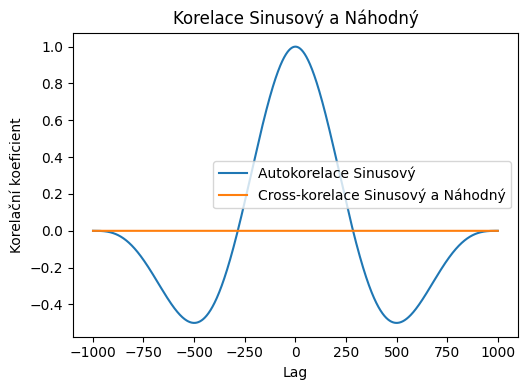

<Figure size 1000x400 with 0 Axes>

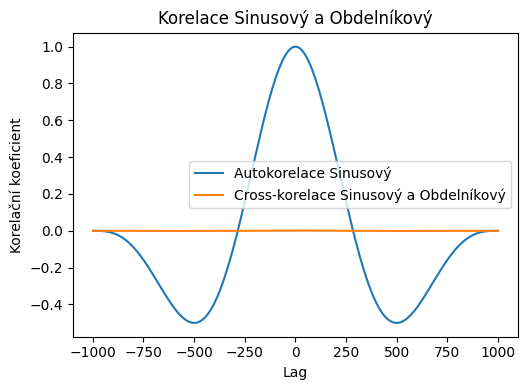

<Figure size 1000x400 with 0 Axes>

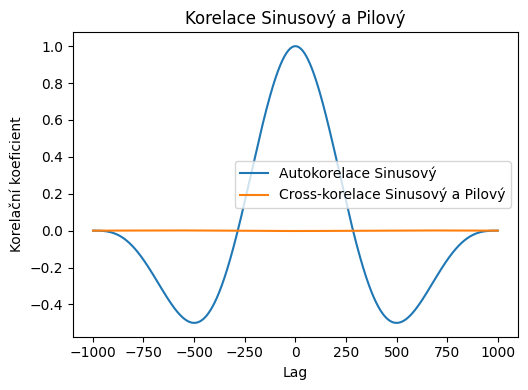

<Figure size 1000x400 with 0 Axes>

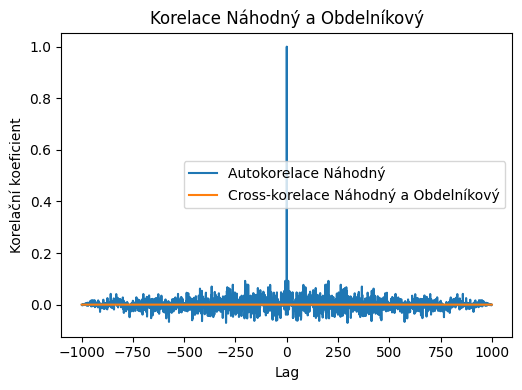

<Figure size 1000x400 with 0 Axes>

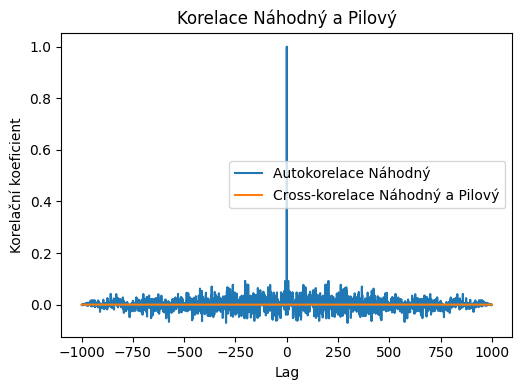

<Figure size 1000x400 with 0 Axes>

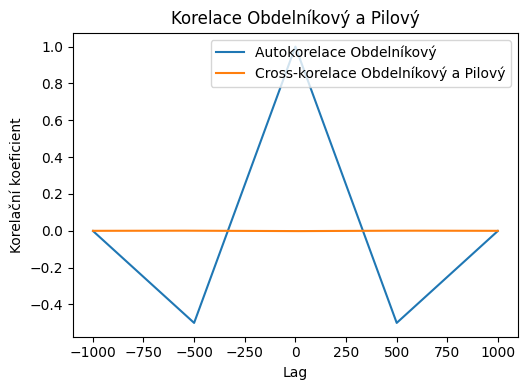

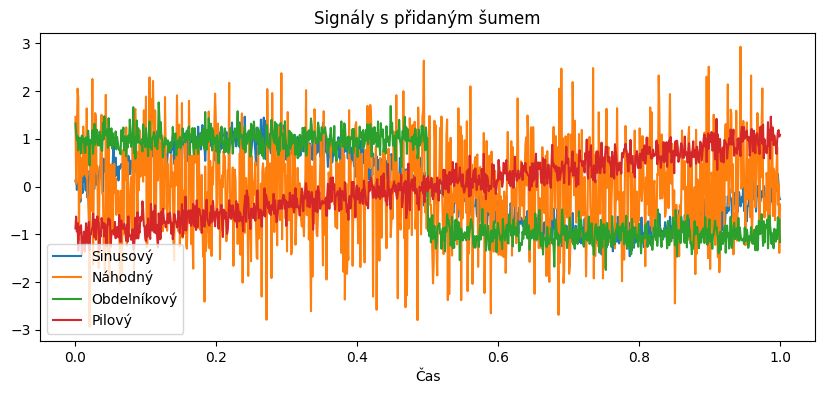

In [11]:
from scipy.signal import correlate

# Nastavení počtu vzorků pro signály
num_samples = 1000
t = np.linspace(0, 1, num_samples)

# Generování sinusového signálu
sin_signal = np.sin(2 * np.pi * t)

# Generování náhodného signálu
np.random.seed(0)
random_signal = np.random.randn(num_samples)

# Generování obdelníkového signálu
square_signal = np.where(t < 0.5, 1, -1)

# Generování pilového signálu
sawtooth_signal = 2 * t - 1

# Funkce pro výpočet a vykreslení autokorelace a cross-korelace
def plot_correlations(signal1, signal2, signal1_name, signal2_name):
    autocorr = correlate(signal1, signal1, mode='full') / np.max(correlate(signal1, signal1, mode='full'))
    crosscorr = correlate(signal1, signal2, mode='full') / (np.max(correlate(signal1, signal1, mode='full')) * np.max(correlate(signal2, signal2, mode='full')))
    
    lags = np.arange(-num_samples + 1, num_samples)
    
    plt.figure(figsize=(10, 4))
    plt.subplot(121)
    plt.plot(lags, autocorr, label=f'Autokorelace {signal1_name}')
    plt.plot(lags, crosscorr, label=f'Cross-korelace {signal1_name} a {signal2_name}')
    plt.title(f'Korelace {signal1_name} a {signal2_name}')
    plt.xlabel('Lag')
    plt.ylabel('Korelační koeficient')
    plt.legend()

# Vytvoření signálů
signals = [sin_signal, random_signal, square_signal, sawtooth_signal]
signal_names = ['Sinusový', 'Náhodný', 'Obdelníkový', 'Pilový']

# Výpočet a vykreslení korelace mezi jednotlivými signály
for i in range(len(signals)):
    for j in range(i+1, len(signals)):
        plt.figure(figsize=(10, 4))
        plot_correlations(signals[i], signals[j], signal_names[i], signal_names[j])
        plt.tight_layout()
        plt.show()

# Přidání šumu k signálům
noisy_signals = [signal + 0.2 * np.random.randn(num_samples) for signal in signals]

# Vykreslení signálů s přidaným šumem
plt.figure(figsize=(10, 4))
for i in range(len(noisy_signals)):
    plt.plot(t, noisy_signals[i], label=signal_names[i])
plt.title('Signály s přidaným šumem')
plt.xlabel('Čas')
plt.legend()
plt.show()

# 5. Cvičení

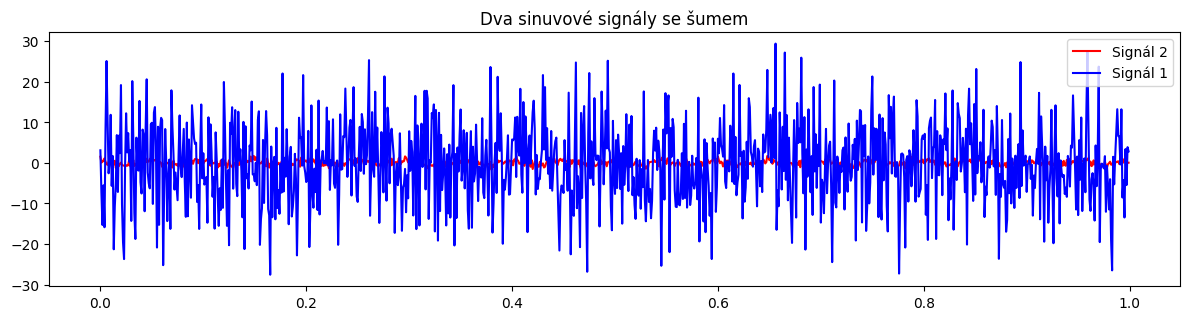

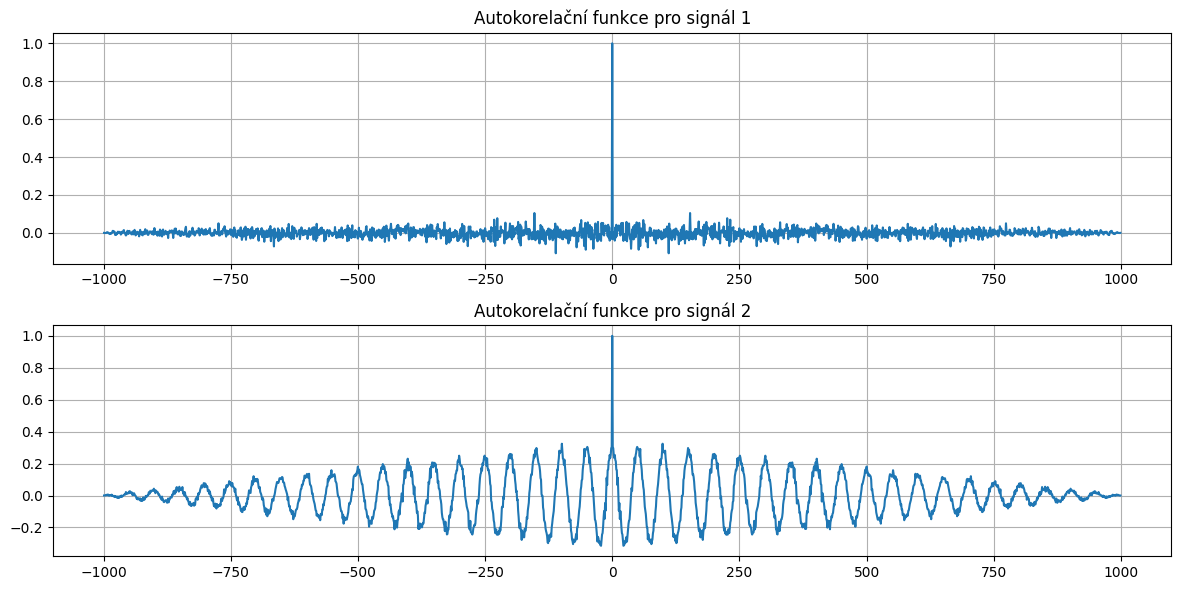

200
1000
200
5


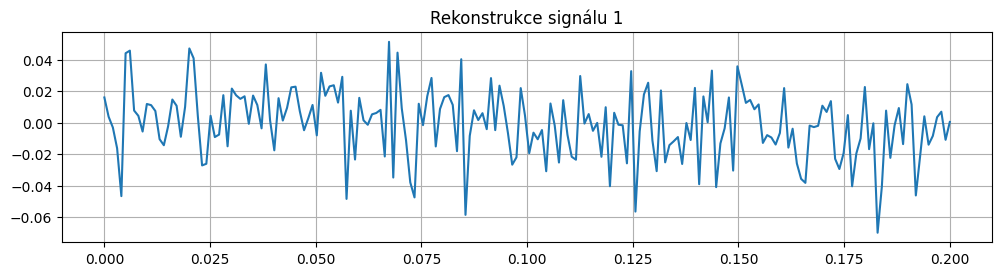

In [12]:
"""
Šum v signálu:

-> Povaha šumu: 
---> Šum může být náhodný nebo systematický a může pocházet z různých zdrojů, jako jsou elektronické komponenty, rušení signálů nebo dokonce kvantové efekty.
---> Náhodný šum může mít různé statistické distribuce, nejčastěji normální (Gaussovský) rozdělení.

Techniky pro odstranění šumu:
-> Kumulační techniky posílení signálu v šumu: Tato metoda zvyšuje poměr signálu k šumu průměrováním více měření nebo použitím technik signálového zpracování, jako je filtrace.
-> Princip metody: Průměrování více měření může zredukovat náhodný šum, protože očekávaná hodnota šumu je nula, což znamená, že se pozitivní a negativní fluktuace šumu vzájemně eliminují.
-> Kumulace s rovnoměrnými váhami: Všechny signály jsou průměrovány s rovnakým vážením, což je vhodné, pokud jsou všechny signály stejně spolehlivé.
-> Okénková kumulace: Signál je průměrován v rámci určitého časového okna, což může pomoci redukovat šum v signálech, které se mění v čase.

Náhodné procesy a korelační techniky:
-> Náhodné signály-procesy: Náhodné procesy produkují signály, jejichž hodnoty nelze předpovědět přesně, ale mají určité statistické vlastnosti, které jsou konzistentní v čase.
-> Princip korelace a autokorelace: Korelace měří, jak jsou dva signály vzájemně podobné, zatímco autokorelace měří, jak je signál podobný sám sobě v různých časových zpožděních. Autokorelace je zvlášť užitečná pro identifikaci skrytých periodicit v signálech s šumem.

"""




import numpy as np
import matplotlib.pyplot as plt

# Nastavení parametrů signálu
n_len = 1000
t = np.linspace(0, 1, n_len, endpoint=False)  # Časový interval od 0 do 1 sekundy, 1000 vzorků
amplitude1 = 1.0  # Am 1
frequency1 = 5  #  fr 1
amplitude2 = 0.5  # Am 2
frequency2 = 20  # fr 2

# signály bez šumu
signal1 = amplitude1 * np.sin(2 * np.pi * frequency1 * t)
signal2 = amplitude2 * np.cos(2 * np.pi * frequency2 * t)

# šum
noise_level_2 = 0.5  # velikost šumu
noise_level_1 = 10
noise1 = noise_level_1 * np.random.randn(len(t))
noise2 = noise_level_2 * np.random.randn(len(t)) 

signal1_with_noise = signal1 + noise1
signal2_with_noise = signal2 + noise2

# vykreslení
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.title("Dva sinuvové signály se šumem")
plt.plot(t, signal2_with_noise, color='red', label='Signál 2')
plt.plot(t, signal1_with_noise, color='blue', label='Signál 1')
plt.legend()
plt.tight_layout()
plt.show()

#-----------------------------------------------------------------------------------------------------------------

# autokorelační funkce
autocorrelation_signal1 = np.correlate(signal1_with_noise, signal1_with_noise, mode='full')
autocorrelation_signal2 = np.correlate(signal2_with_noise, signal2_with_noise, mode='full')

# normalizace na hodnotu -1 až 1
autocorrelation_signal1 /= np.max(autocorrelation_signal1)
autocorrelation_signal2 /= np.max(autocorrelation_signal2)

# useknutí signálu
autocorrelation_signal1


plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.title("Autokorelační funkce pro signál 1")
plt.plot(np.arange(-len(signal1_with_noise) + 1, len(signal1_with_noise)), autocorrelation_signal1)
plt.grid(True)
plt.subplot(2, 1, 2)
plt.title("Autokorelační funkce pro signál 2")
plt.plot(np.arange(-len(signal2_with_noise) + 1, len(signal2_with_noise)), autocorrelation_signal2)
plt.grid(True)
plt.tight_layout()
plt.show()



#-----------------------------------------------------------------------------------------------------------------

# rekonstrukce podle jedné periody
len_per_1 = int(n_len/5)
#len_per_2 = int(n_len/0.5)
print(len_per_1)
print(len(signal1_with_noise))
periods_1 = np.reshape(signal1_with_noise, [frequency1, len_per_1])
#periods_2 = np.reshape(signal2_with_noise,[frequency2, len_per_2])
T1 = 1/frequency1
T2 = 1/frequency2
print(len_per_1)
print(len(periods_1))


newsignal = np.sum(periods_1,axis=0)
newsignal /=n_len

tone1=np.linspace(0,T1,len_per_1)


plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.title("Rekonstrukce signálu 1")
plt.plot(tone1,newsignal)
plt.grid(True)
#plt.plot(Tone1,mojeFunkce(f,Tone))

# 6. Cvičení: Frekvenční analýza signálu

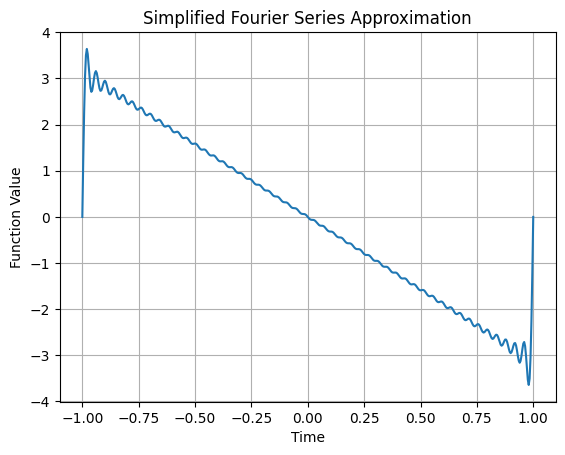

In [13]:
"""
Frekvenční analýza signálu
-> Frekvenční analýza signálu je proces zkoumání signálu ve frekvenční oblasti, což nám umožňuje zjistit, které frekvence jsou v signálu přítomné a jaká je jejich amplituda. 
-> Tento proces je klíčový pro mnoho aplikací v elektrotechnice, hudbě, akustice a dalších oborech.

Fourierova transformace (FT): 
-> Matematický nástroj, který převádí signál z časové oblasti (kde je zobrazen jako funkce času) do frekvenční oblasti (kde je zobrazen jako funkce frekvence). 
-> FT rozloží signál na sinusové a kosinusové vlny různých frekvencí, což ukazuje, jaké frekvence jsou v signálu přítomné a jaký je jejich příspěvek k celkovému signálu.

Rychlá Fourierova transformace (FFT): 
-> Je to efektivní algoritmus pro výpočet Fourierovy transformace, který je široce používán ve výpočetní technice pro snížení výpočetní složitosti

Spektrum: 
-> Výsledek FT nebo FFT, který ukazuje amplitudy (nebo někdy také fáze) různých frekvenčních komponent signálu. Spektrum může být zobrazeno jako amplitudové spektrum nebo fázové spektrum.

Spektrální hustota výkonu (Power Spectral Density, PSD): 
-> Tato funkce ukazuje distribuci energie signálu v rámci různých frekvencí a často se používá pro analýzu šumových signálů a harmonických komponent.

Filtrace: 
-> Proces výběru nebo potlačení určitých frekvencí v signálu. Může se jednat o nízké propusti (propouštění nízkých frekvencí a zastavení vysokých), vysoké propusti (propouštění vysokých frekvencí a zastavení nízkých), pásmové propusti (propouštění frekvencí v určitém pásmu) nebo pásmové zádrže (zastavení frekvencí v určitém pásmu).

Fourierova řada
-> je matematický nástroj používaný k rozkladu periodických funkcí na sumu sinusových a kosinusových funkcí různých frekvencí. 
-> Každá funkce, která je periodická a splňuje určité matematické podmínky (Dirichletovy podmínky), může být vyjádřena jako Fourierova řada.
-> je předchůdcem Fourierovy transformace, která rozšiřuje tento koncept na neperiodické funkce, umožňuje analýzu signálů v nekonečně dlouhém časovém intervalu a je základem moderního zpracování signálů.

Analýza signálů: 
-> Fourierova řada umožňuje analyzovat složitější signály rozložením na jednodušší periodické komponenty. To je obzvláště užitečné v elektrotechnice a zpracování signálů.

Řešení fyzikálních problémů: 
-> V mnoha fyzikálních problémech, například ve studiu vibrací a vlnění, se Fourierovy řady používají k rozkladu složitých pohybů na jednodušší sinusové a kosinusové vlny, které jsou snáze analyzovatelné.

Hudební teorie: 
-> V hudbě Fourierova řada popisuje, jak lze složité zvukové vlny, jako jsou hudební tóny, vyjádřit jako součet jednoduchých harmonických vln.
"""

import numpy as np
import matplotlib.pyplot as plt

# Váš původní kód s menší úpravou, která aplikuje Fourierovu řadu
def f(n, t):
    seznam = np.zeros_like(t)  # Inicializuje seznam nulami o stejné velikosti jako t
    for i in range(1, n):
        x = (2 / i) * (-1)**i * np.sin(i * np.pi * t)  # Výpočet Fourierova členu pro i-tý termín
        seznam += x  # Přičítá výsledný termín do seznamu
    return seznam

# Počet termínů a časový interval
n_terms = 50
t = np.linspace(-1, 1, 500)  # Toto je pro jedno období (-1 až 1), předpokládáme f = 1

# Vypočítáme Fourierovu řadu pro zadaný počet termínů a časový interval
funkce = f(n_terms, t)

# Vykreslíme výsledek
plt.plot(t, funkce)
plt.xlabel('Time')
plt.ylabel('Function Value')
plt.title('Simplified Fourier Series Approximation')
plt.grid(True)
plt.show()